In [1]:
#Загрузка датасет через Yahoo Finance + oilpriseapi
import yfinance as yf
import pandas as pd
import requests
from datetime import datetime

def get_full_oil_dataset(api_key, symbol="BZ=F", code="BRENT_CRUDE_USD"):
        
    # 1. ЗАГРУЗКА ИСТОРИИ (из Yahoo Finance)
    print("Загрузка истории из Yahoo Finance...")
    # Берем историю за последние 10 лет
    history = yf.download(symbol, period="10y", interval="1d")
    # ИСПРАВЛЕНИЕ ОШИБКИ: Сплющиваем MultiIndex, если он есть
    if isinstance(history.columns, pd.MultiIndex):
        history.columns = history.columns.get_level_values(0)
    
    # Оставляем только цену закрытия и переименовываем
    history = history[['Close']].rename(columns={'Close': 'price'})
    history.index = pd.to_datetime(history.index).tz_localize(None)
    
    # 2. ЗАГРУЗКА СВЕЖИХ ДАННЫХ (из OilPriceAPI)
    print("Получение оперативных данных из OilPriceAPI...")

    base_url = "https://api.oilpriceapi.com/v1/prices/latest"
    params = {"by_code": code}
    headers = {"Authorization": f"Token {api_key}", 
               "Content-Type": "application/json" }
    
    try:
        response = requests.get(base_url, params=params, headers=headers)
       
        if response.status_code == 200:
            live_data = response.json()['data']
            live_price = live_data['price']
            live_date = pd.to_datetime(live_data['created_at']).replace(tzinfo=None).normalize()
            
            # Создаем строку с сегодняшней ценой
            live_df = pd.DataFrame({'price': [live_price]}, index=[live_date])
            
            # 3. СКЛЕЙКА (добавляем свежую цену, если её еще нет в истории)
            if live_date not in history.index:
                full_df = pd.concat([history, live_df])
                print(f"Добавлена актуальная цена: {live_price}")
            else:
                full_df = history
                print("Данные Yahoo уже содержат актуальную цену.")
                
            return full_df.sort_index()
        else:  print(f"Текст ответа: {response.text}")    
    except Exception as e:
        print(f"Ошибка при обращении к API: {e}. Используем только историю.")
        print(f"Текст ответа: {response.text}") 
        return history


API_KEY = 'ddad96c30dcd94010d427c8d30cfa7a2d9a7a3a347e3ef77b465fc952f5b19e5'
data = get_full_oil_dataset(API_KEY)

Загрузка истории из Yahoo Finance...


[*********************100%***********************]  1 of 1 completed


Получение оперативных данных из OilPriceAPI...
Данные Yahoo уже содержат актуальную цену.


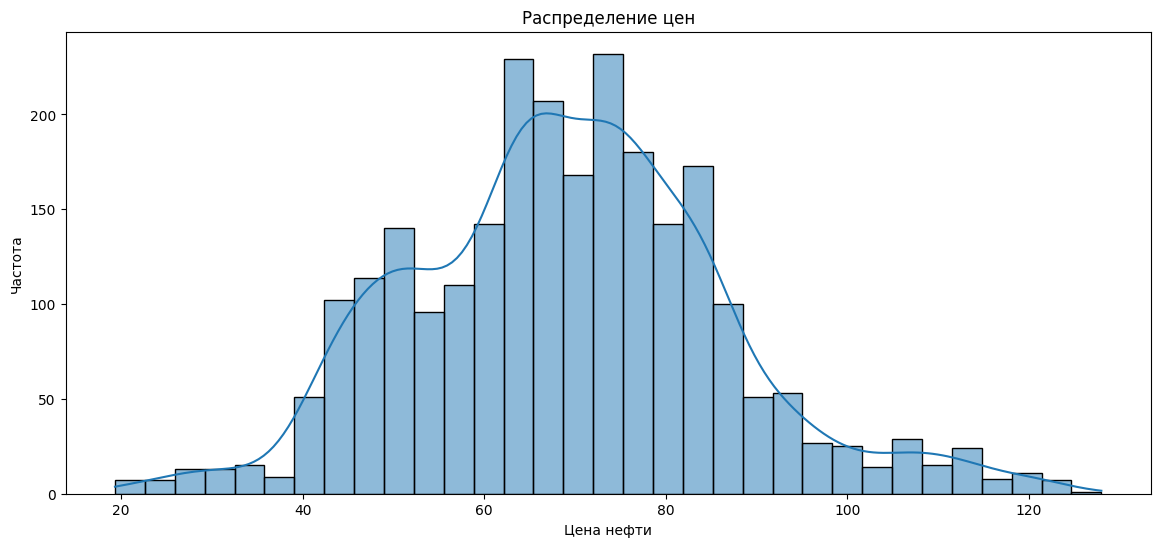

In [3]:
# Распределение цены нефти
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import matplotlib.dates as mdates
plt.figure(figsize=(14, 6))
sns.histplot(data['price'], kde=True)
plt.title('Распределение цен')
plt.xlabel('Цена нефти')
plt.ylabel('Частота')
plt.show()

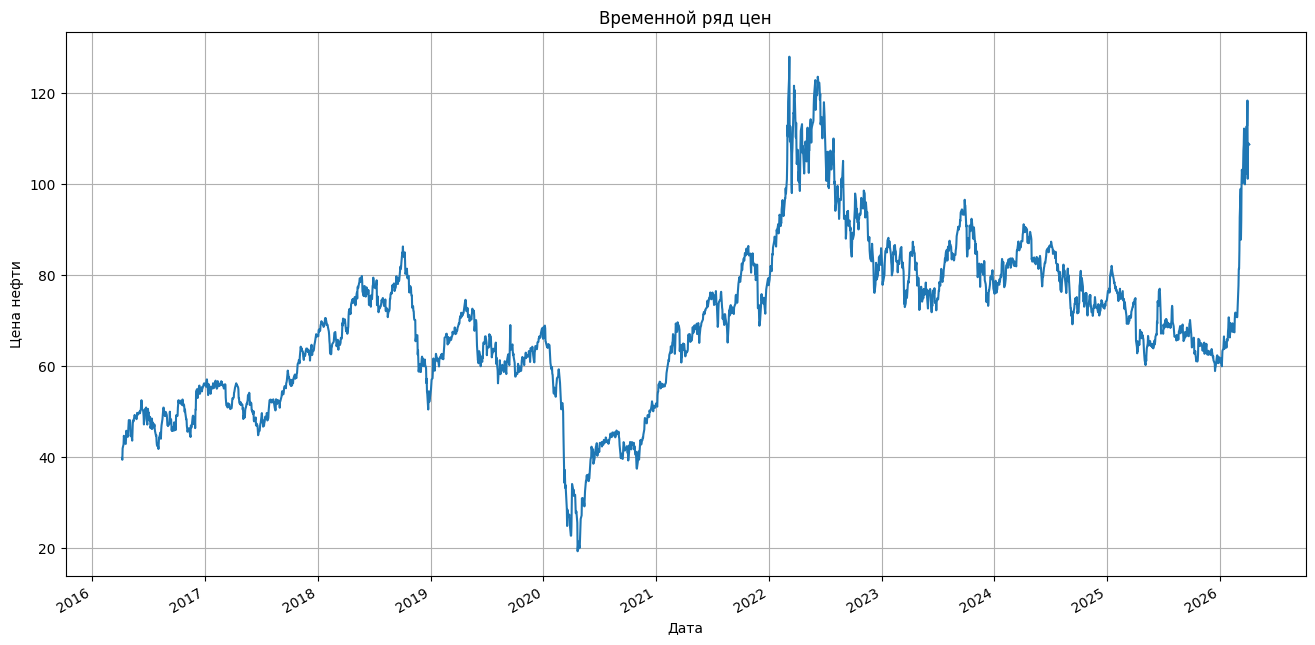

In [4]:
# Временной ряд
plt.figure(figsize=(16, 8))
plt.plot(data.index, data['price'])
plt.title('Временной ряд цен')
plt.xlabel('Дата')
plt.ylabel('Цена нефти')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

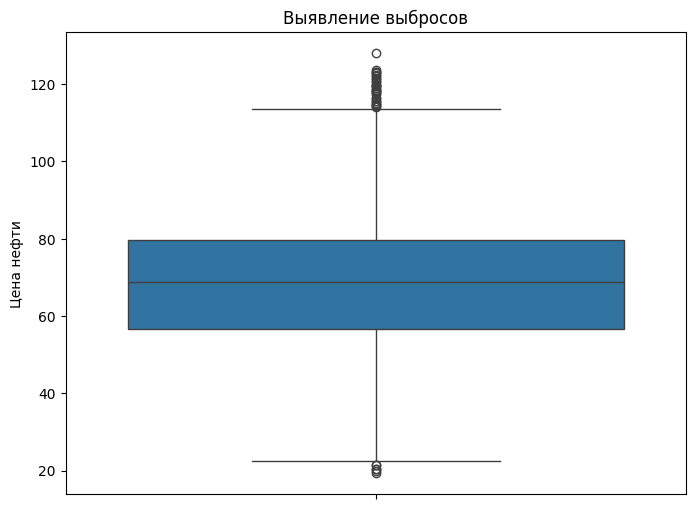

In [5]:
# Боксплот для выявления выбросов
plt.figure(figsize=(8, 6))
sns.boxplot(y=data['price'])
plt.title('Выявление выбросов')
plt.ylabel('Цена нефти')
plt.show()



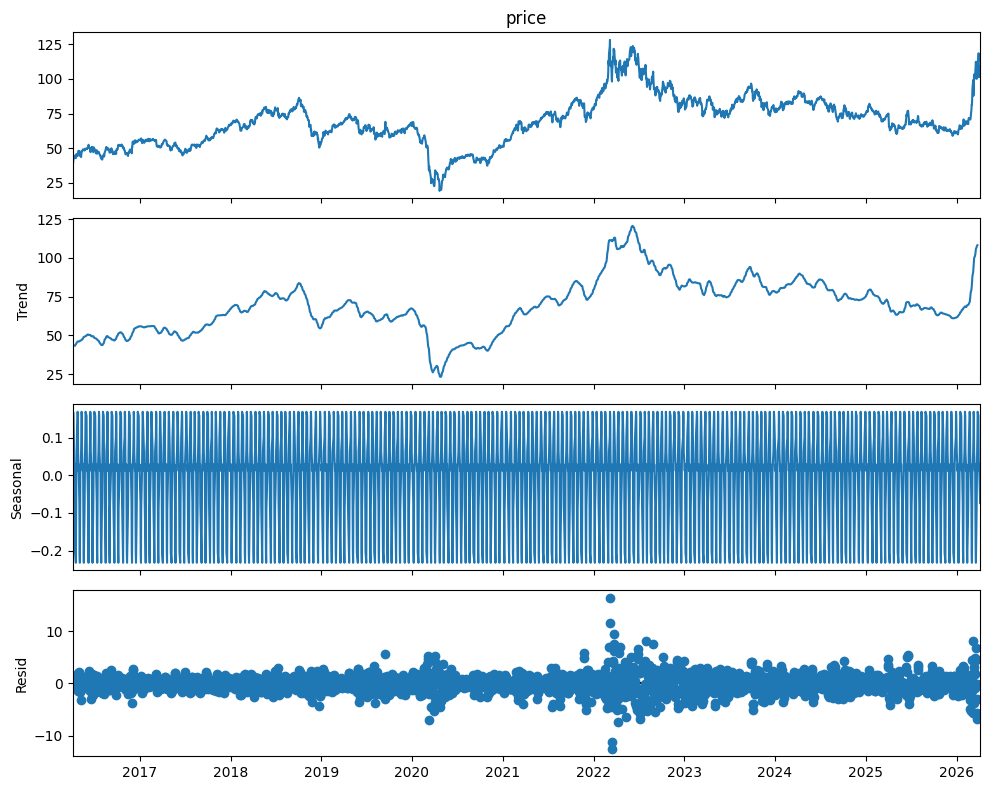

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
# Декомпозиция (период 12 месяцев)
result = seasonal_decompose(data['price'], model='additive', period=12)

# Визуализация
plt.rcParams['figure.figsize'] = (10, 8)
result.plot()
plt.show()

In [8]:
result = adfuller(data['price'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
   # Главное правило интерпретации:
if result[1] <= 0.05:
    print("Ряд стационарен")
else:
    print("Ряд нестационарен (требуется дифференцирование)")

ADF Statistic: -2.0005
p-value: 0.2863
Ряд нестационарен (требуется дифференцирование)


In [9]:
from sklearn.preprocessing import MinMaxScaler
# Нормализация данных
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data.values.reshape(-1,1))


In [10]:
# Создание обучающих последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:(i+seq_length)])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)
# Разделение на выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [11]:
#Создание прогнозируемой выборки
def create_sequences_pred(data, seq_length,horizon):
    X, y = [], []
    for i in range(len(scaled_data) - seq_length - horizon + 1):
        X.append(scaled_data[i:(i + seq_length), 0])
        y.append(scaled_data[(i + seq_length):(i + seq_length + horizon), 0])
    return np.array(X), np.array(y)

In [12]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    GRU, LSTM, SimpleRNN, Dense, Dropout, Input,
    Conv1D, MaxPooling1D, Flatten
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.dates as mdates
from tensorflow.keras.callbacks import EarlyStopping

# Функция для построения моделей
def build_model(model_type,step=1):
    input_layer = Input(batch_shape=(None, X_train.shape[1], 1))

    if model_type == 'GRU':
        x = GRU(50, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = GRU(50, return_sequences=False)(x)

    elif model_type == 'LSTM':
        x = LSTM(100, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = LSTM(50, return_sequences=False)(x)

    elif model_type == 'RNN':
        x = SimpleRNN(50, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = SimpleRNN(50, return_sequences=False)(x)

    elif model_type == 'CNN':
        x = Conv1D(filters=64, kernel_size=3, activation='relu')(input_layer)
        x = MaxPooling1D(pool_size=2)(x)
        x = Flatten()(x)

    elif model_type == 'Autoencoder':
        # Encoder часть
        x = Dense(128, activation='relu')(input_layer)
        x = Dense(64, activation='relu')(x)

        # Bottleneck
        encoded = Dense(32, activation='relu')(x)

        # Decoder часть
        x = Dense(64, activation='relu')(encoded)
        x = Dense(128, activation='relu')(x)

        # Выходной слой
        x = Flatten()(x)

    x = Dropout(0.2)(x)
    output_layer = Dense(units=step)(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [13]:
# Обучение моделей
models = {}
results = {}

for model_type in ['GRU', 'LSTM', 'RNN', 'CNN', 'Autoencoder']:
    print(f"\nTraining {model_type} model...")

    # Создаем модель
    model = build_model(model_type)
    models[model_type] = model

    # Добавляем Early Stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Обучаем модель
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    # Сохраняем историю обучения
    results[model_type] = {
        'history': history,
        'model': model
    }



Training GRU model...
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0175 - val_loss: 0.0034
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0029 - val_loss: 5.0020e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0024 - val_loss: 5.5625e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0021 - val_loss: 8.1129e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0024 - val_loss: 9.2156e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0020 - val_loss: 5.4693e-04
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0021 - val_loss: 8.3046e-04
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0020 - val_loss: 9.5615e-04
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0018 - val_loss: 4.8040e-04
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0017 - val_loss: 4.4122e-04
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0018 - val_loss: 0.0011
Ep

In [14]:
# Функция для оценки моделей
def evaluate_model(model, X_test, y_test, scaler):
    # Прогнозирование
    test_predict = model.predict(X_test)

    # Обратное преобразование масштабирования
    test_predict = scaler.inverse_transform(test_predict)
    y_true = scaler.inverse_transform(y_test.reshape(-1,1))

    # Метрики
    rmse = np.sqrt(mean_squared_error(y_true, test_predict))
    mae = mean_absolute_error(y_true, test_predict)
    r2 = r2_score(y_true, test_predict)
    mape = mean_absolute_percentage_error(y_true, test_predict) * 100

    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'predictions': test_predict
    }

# Оценка всех моделей
evaluation_results = {}

for model_type in models:
    print(f"\nОцениваем модель {model_type}...")
    evaluation_results[model_type] = evaluate_model(
        models[model_type],
        X_test,
        y_test,
        scaler
    )


Оцениваем модель GRU...
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step

Оцениваем модель LSTM...
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step

Оцениваем модель RNN...
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

Оцениваем модель CNN...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Оцениваем модель Autoencoder...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [15]:
# Визуализация результатов
def plot_results(model_type):
    plt.figure(figsize=(16, 8))
    plt.plot(data.index[sequence_length:],
             scaler.inverse_transform(y.reshape(-1,1)),
             label='Реальные данные', color='blue')

    plt.plot(data.index[-len(evaluation_results[model_type]['predictions']):],
             evaluation_results[model_type]['predictions'],
             label=f'Прогнозы {model_type}', color='red')

    plt.title(f'Прогноз цен на нефть с помощью {model_type}')
    plt.xlabel('Дата')
    plt.ylabel('Цена нефти')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gcf().autofmt_xdate()
    plt.show()



Результаты для модели GRU:
RMSE: 1.97
MAE: 1.27
R2: 0.9581
MAPE: 1.67%


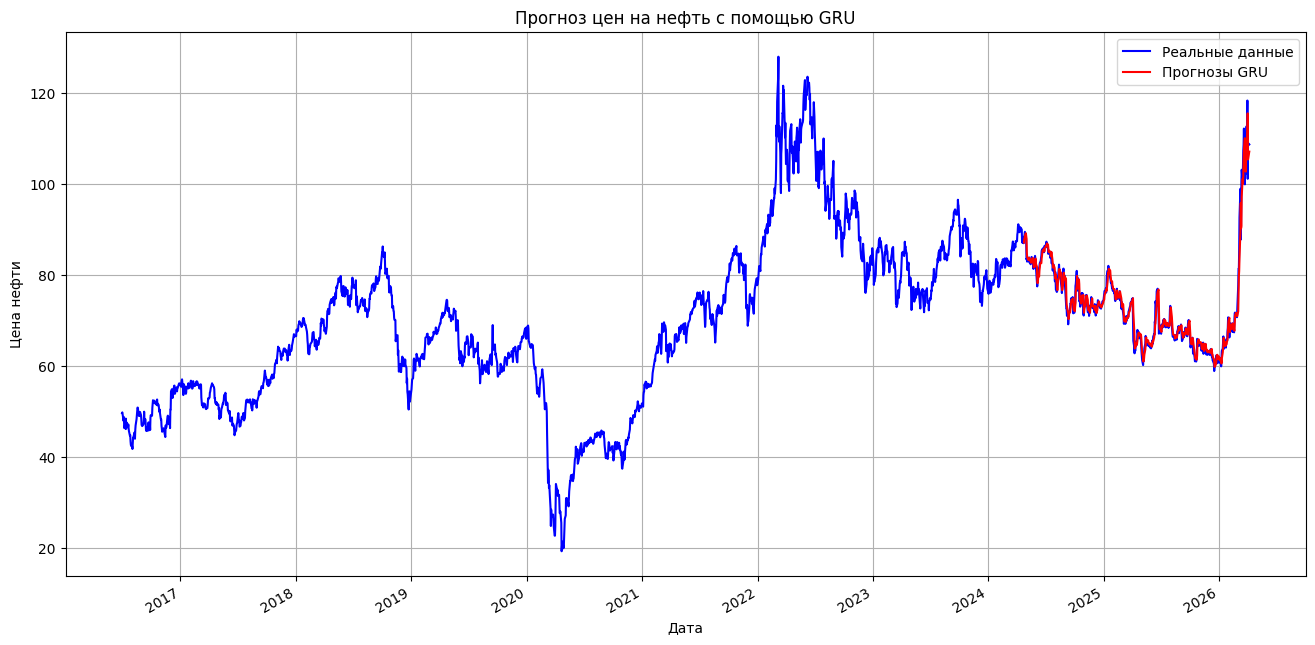


Результаты для модели LSTM:
RMSE: 2.40
MAE: 1.62
R2: 0.9378
MAPE: 2.14%


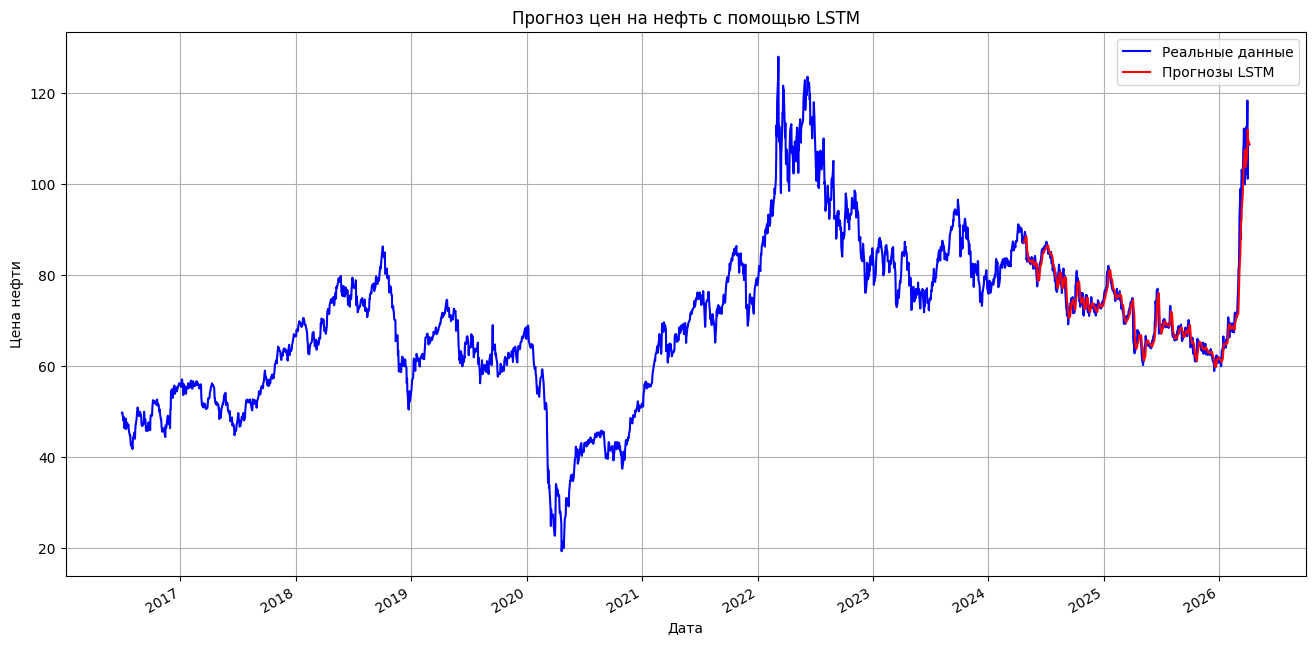


Результаты для модели RNN:
RMSE: 1.97
MAE: 1.28
R2: 0.9582
MAPE: 1.70%


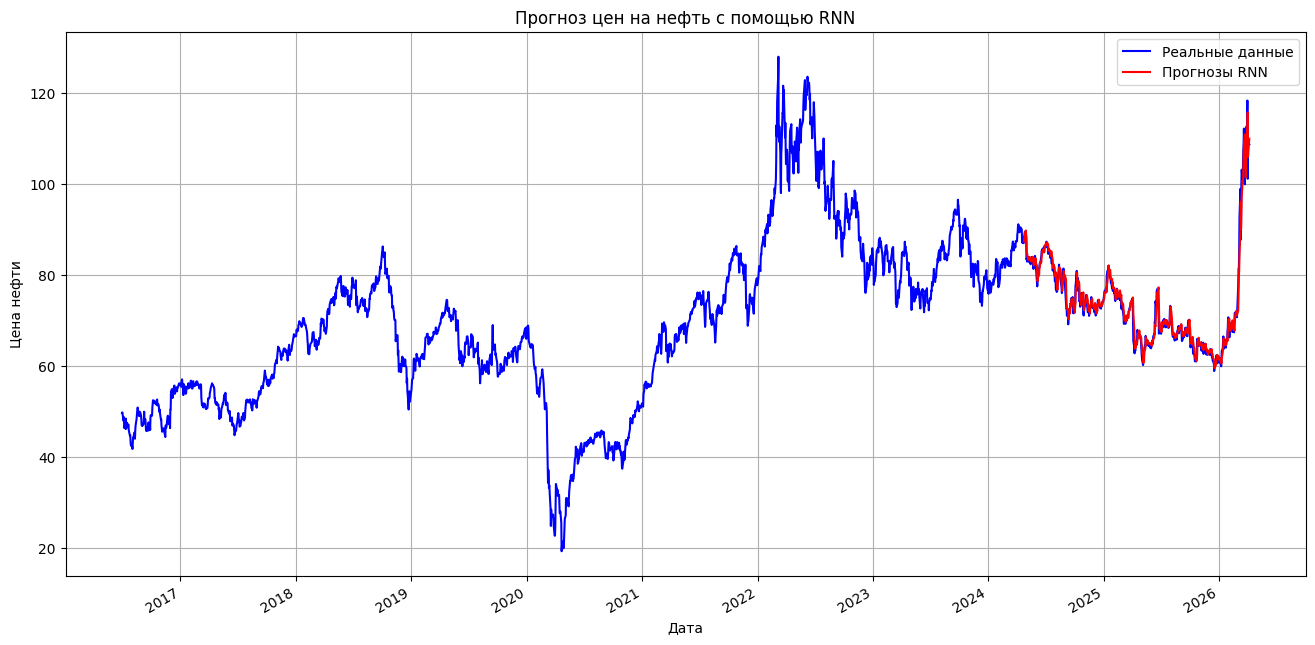


Результаты для модели CNN:
RMSE: 2.62
MAE: 1.74
R2: 0.9258
MAPE: 2.29%


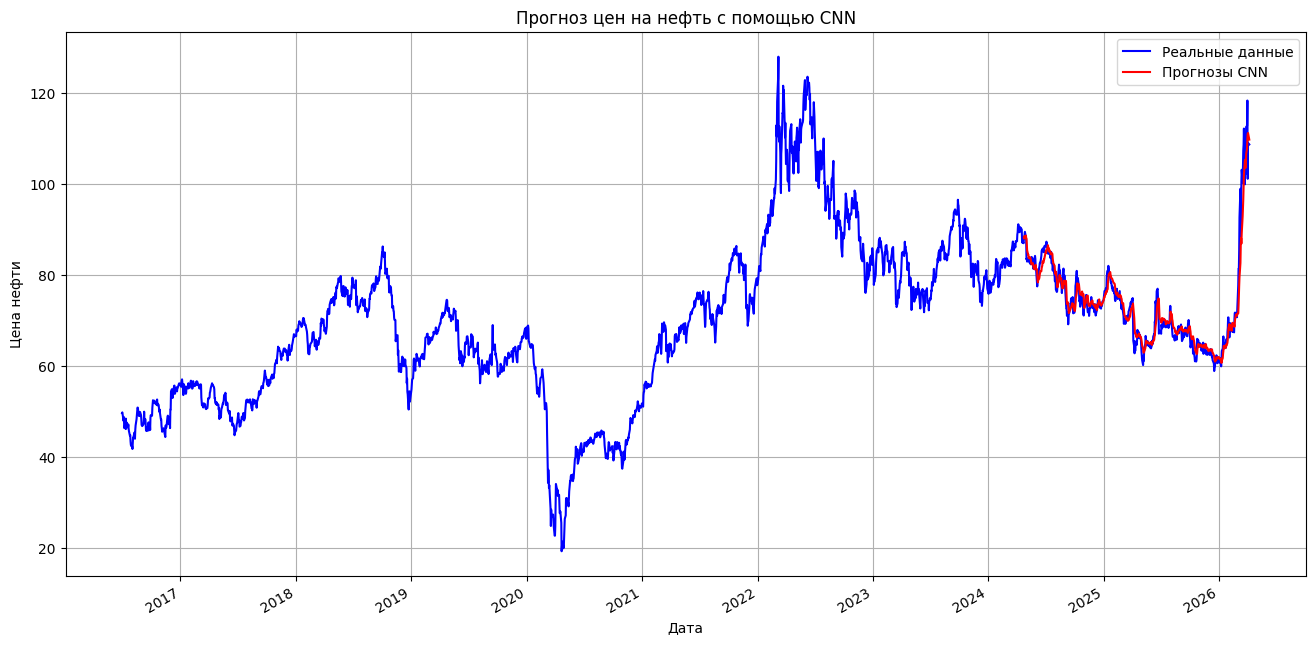


Результаты для модели Autoencoder:
RMSE: 2.45
MAE: 1.72
R2: 0.9351
MAPE: 2.32%


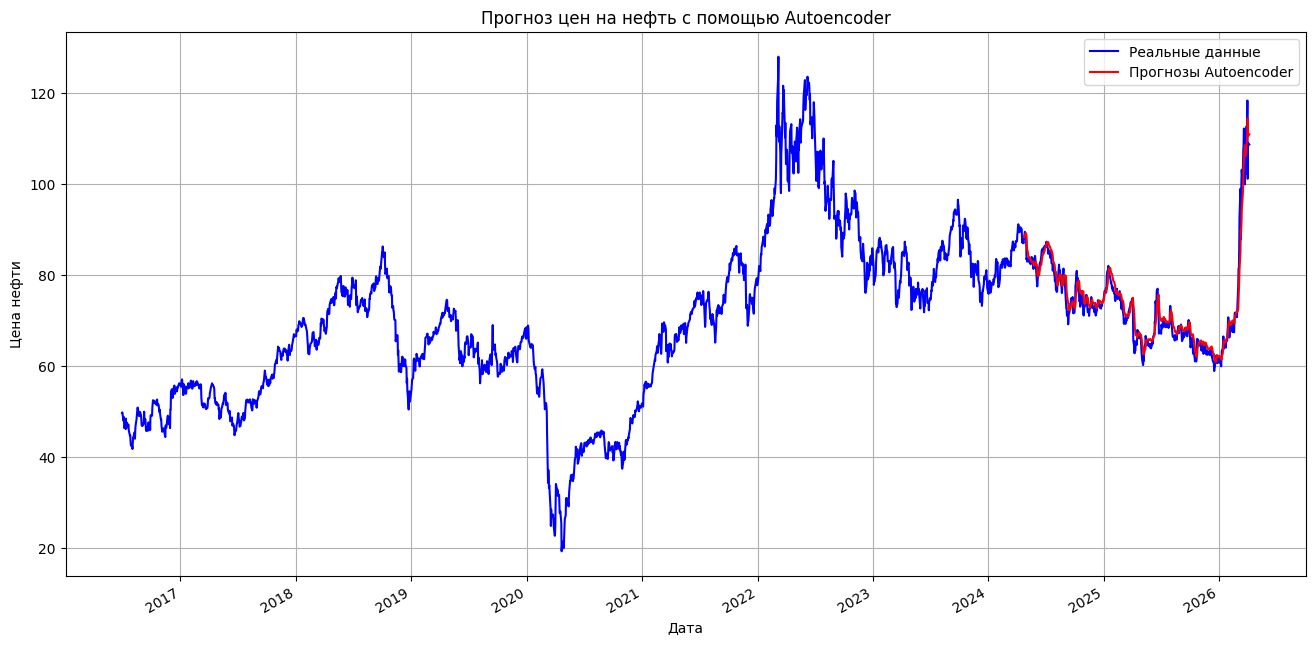

In [16]:
# Визуализация ошибок
def plot_error_comparison():
    plt.figure(figsize=(14, 7))
    for model_type in evaluation_results:
        errors = evaluation_results[model_type]['predictions'] - scaler.inverse_transform(y_test.reshape(-1,1))
        plt.plot(
            data.index[-len(errors):],
            errors.flatten(),
            label=model_type
        )
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title('Сравнение ошибок моделей')
    plt.xlabel('Дата')
    plt.ylabel('Ошибка прогноза')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gcf().autofmt_xdate()
    plt.show()

# Визуализация всех моделей
for model_type in models:
    print(f"\nРезультаты для модели {model_type}:")
    print(f"RMSE: {evaluation_results[model_type]['RMSE']:.2f}")
    print(f"MAE: {evaluation_results[model_type]['MAE']:.2f}")
    print(f"R2: {evaluation_results[model_type]['R2']:.4f}")
    print(f"MAPE: {evaluation_results[model_type]['MAPE']:.2f}%")
    
    plot_results(model_type)


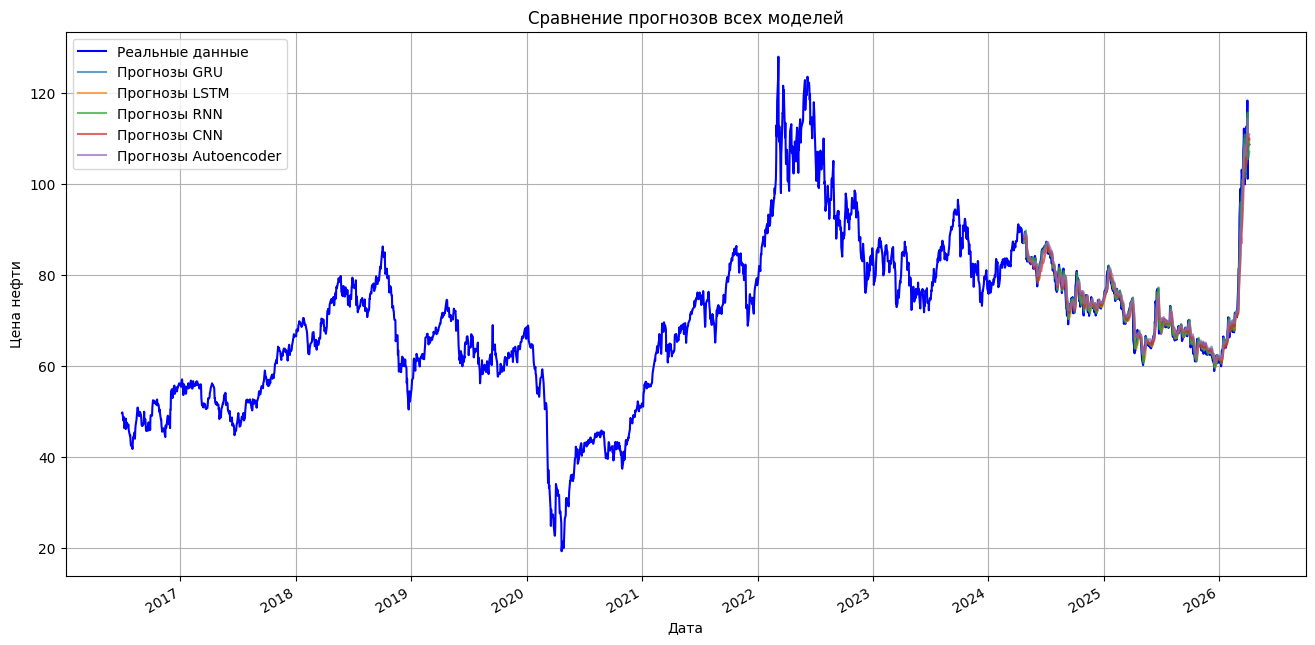

In [17]:
# Дополнительная визуализация - сравнение прогнозов
plt.figure(figsize=(16, 8))
plt.plot(
    data.index[sequence_length:],
    scaler.inverse_transform(y.reshape(-1,1)),
    label='Реальные данные',
    color='blue'
)

for model_type in evaluation_results:
    plt.plot(
        data.index[-len(evaluation_results[model_type]['predictions']):],
        evaluation_results[model_type]['predictions'],
        label=f'Прогнозы {model_type}',
        alpha=0.7
    )

plt.title('Сравнение прогнозов всех моделей')
plt.xlabel('Дата')
plt.ylabel('Цена нефти')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()


In [18]:
# Сравнение метрик
comparison_df = pd.DataFrame({
    'Модель': list(evaluation_results.keys()),
    'RMSE': [res['RMSE'] for res in evaluation_results.values()],
    'MAE': [res['MAE'] for res in evaluation_results.values()],
    'R2': [res['R2'] for res in evaluation_results.values()],
    'MAPE': [res['MAPE'] for res in evaluation_results.values()]
})

print("\nСравнение метрик моделей:")
print(comparison_df)
# Функция для построения графиков сравнения метрик
def plot_metric_comparison(metric_name):
    plt.figure(figsize=(12, 6))
    plt.bar(
        comparison_df['Модель'],
        comparison_df[metric_name],
        color=['blue', 'green', 'orange', 'red', 'purple']
    )

    plt.title(f'Сравнение {metric_name} по моделям')
    plt.xlabel('Модели')
    plt.ylabel(metric_name)
    plt.grid(axis='y')
    plt.ylim(bottom=0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Сравнение метрик моделей:
        Модель      RMSE       MAE        R2      MAPE
0          GRU  1.970867  1.268025  0.958052  1.673735
1         LSTM  2.399517  1.617391  0.937820  2.144973
2          RNN  1.967764  1.279327  0.958184  1.695806
3          CNN  2.621923  1.739515  0.925760  2.293083
4  Autoencoder  2.451369  1.722679  0.935104  2.318023



Визуализация сравнения метрик:


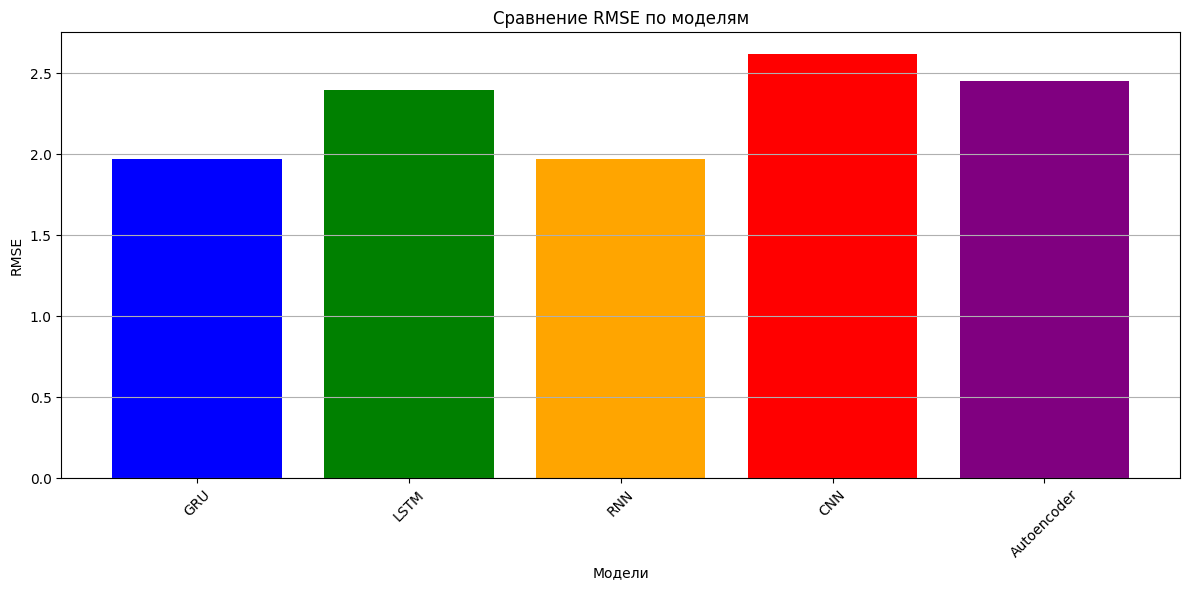

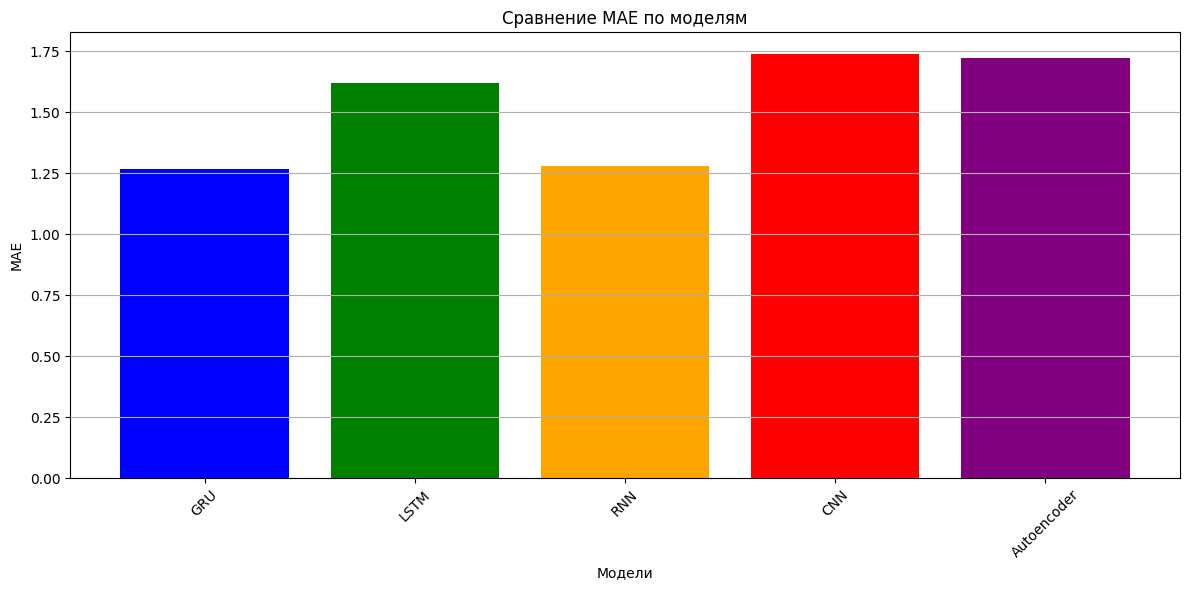

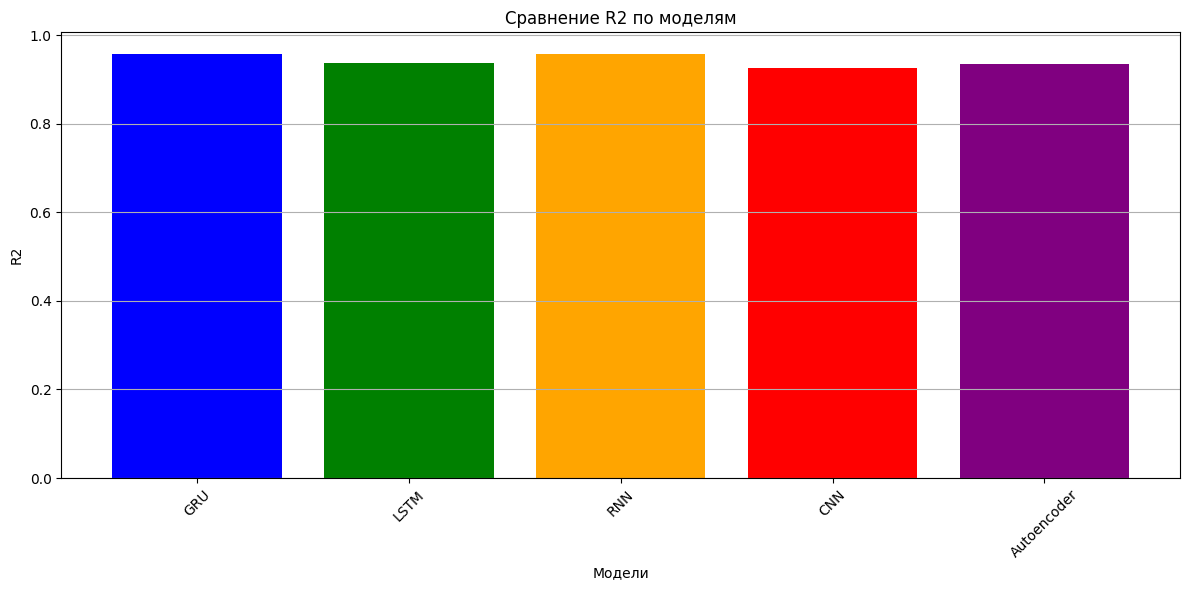

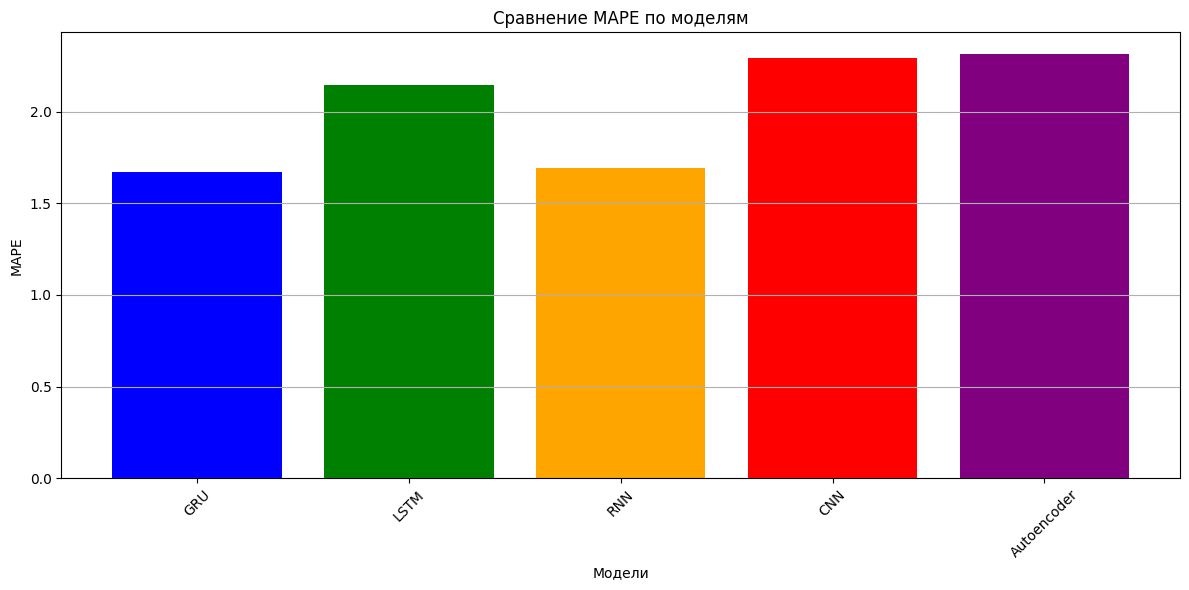


РЕЗУЛЬТАТЫ АНАЛИЗА МОДЕЛЕЙ:
----------------------------------------

СРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ:
        Модель      RMSE       MAE        R2      MAPE
0          GRU  1.970867  1.268025  0.958052  1.673735
1         LSTM  2.399517  1.617391  0.937820  2.144973
2          RNN  1.967764  1.279327  0.958184  1.695806
3          CNN  2.621923  1.739515  0.925760  2.293083
4  Autoencoder  2.451369  1.722679  0.935104  2.318023


РЕКОМЕНДУЕМАЯ МОДЕЛЬ:
******************** RNN ********************
ОСНОВАНИЕ РЕКОМЕНДАЦИИ:
Модель RNN показала наилучший баланс между:
- Максимальным коэффициентом детерминации (R2)
- Минимальными ошибками прогнозирования (RMSE, MAE, MAPE)


РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:
**************************************************
НАИБОЛЕЕ ЭФФЕКТИВНОЙ МОДЕЛЬЮ ЯВЛЯЕТСЯ: RNN
**************************************************
РЕКОМЕНДУЕТСЯ ИСПОЛЬЗОВАТЬ ДАННУЮ МОДЕЛЬ ДЛЯ:
- Прогнозирования цен на золото
- Анализа временных рядов
- Принятия инвестиционных решений

ОГРАНИЧЕНИЯ П

In [19]:
# Функция для построения сравнительных графиков всех метрик
def plot_all_metrics():
    metrics = ['RMSE', 'MAE', 'R2', 'MAPE']

    plt.figure(figsize=(16, 12))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        plt.bar(
            comparison_df['Модель'],
            comparison_df[metric],
            color=['blue', 'green', 'orange', 'red', 'purple']
        )

        plt.title(f'Сравнение {metric}')
        plt.xlabel('Модели')
        plt.ylabel(metric)
        plt.grid(axis='y')
        plt.ylim(bottom=0)
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Добавляем визуализацию сравнения метрик
print("\nВизуализация сравнения метрик:")

# Построим отдельные графики для каждой метрики
plot_metric_comparison('RMSE')
plot_metric_comparison('MAE')
plot_metric_comparison('R2')
plot_metric_comparison('MAPE')

# Функция для определения лучшей модели на основе метрик
def determine_best_model(results):
    # Собираем все метрики в DataFrame
    comparison_df = pd.DataFrame({
        'Модель': list(results.keys()),
        'RMSE': [res['RMSE'] for res in results.values()],
        'MAE': [res['MAE'] for res in results.values()],
        'R2': [res['R2'] for res in results.values()],
        'MAPE': [res['MAPE'] for res in results.values()]
    })

    # Определяем лучшую модель по R2 и RMSE
    best_r2_model = comparison_df.loc[comparison_df['R2'].idxmax()]['Модель']
    best_rmse_model = comparison_df.loc[comparison_df['RMSE'].idxmin()]['Модель']

    # Если совпадают - это наш выбор
    if best_r2_model == best_rmse_model:
        return best_r2_model
    else:
        # Если не совпадают - выбираем по среднему баллу
        comparison_df['Средний_балл'] = (comparison_df['R2'] +
                                        1/comparison_df['RMSE'] +
                                        1/comparison_df['MAE'] +
                                        1/comparison_df['MAPE'])
        return comparison_df.loc[comparison_df['Средний_балл'].idxmax()]['Модель']

# Определяем лучшую модель
best_model = determine_best_model(evaluation_results)

# Выводим результаты анализа
print("\nРЕЗУЛЬТАТЫ АНАЛИЗА МОДЕЛЕЙ:")
print("-" * 40)

# Сравнение метрик
comparison_df = pd.DataFrame({
    'Модель': list(evaluation_results.keys()),
    'RMSE': [res['RMSE'] for res in evaluation_results.values()],
    'MAE': [res['MAE'] for res in evaluation_results.values()],
    'R2': [res['R2'] for res in evaluation_results.values()],
    'MAPE': [res['MAPE'] for res in evaluation_results.values()]
})

print("\nСРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ:")
print(comparison_df)

# Вывод лучшей модели
print("\n\nРЕКОМЕНДУЕМАЯ МОДЕЛЬ:")
print(f"{'*'*20} {best_model} {'*'*20}")
print(f"ОСНОВАНИЕ РЕКОМЕНДАЦИИ:")
print(f"Модель {best_model} показала наилучший баланс между:")
print(f"- Максимальным коэффициентом детерминации (R2)")
print(f"- Минимальными ошибками прогнозирования (RMSE, MAE, MAPE)")

# ... остальной код ...

# Добавляем вывод в конце визуализации
print("\n\nРЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:")
print(f"{'*'*50}")
print(f"НАИБОЛЕЕ ЭФФЕКТИВНОЙ МОДЕЛЬЮ ЯВЛЯЕТСЯ: {best_model}")
print(f"{'*'*50}")
print("РЕКОМЕНДУЕТСЯ ИСПОЛЬЗОВАТЬ ДАННУЮ МОДЕЛЬ ДЛЯ:")
print("- Прогнозирования цен на золото")
print("- Анализа временных рядов")
print("- Принятия инвестиционных решений")
print("\nОГРАНИЧЕНИЯ ПРИМЕНЕНИЯ:")
if best_model == 'GRU':
    print("Требует большого объема данных для обучения")
elif best_model == 'LSTM':
    print("Может быть ресурсоемкой при больших выборках")
elif best_model == 'RNN':
    print("Менее эффективна для долгосрочных зависимостей")
elif best_model == 'CNN':
    print("Лучше работает с сезонными данными")
elif best_model == 'Autoencoder':
    print("Требует дополнительной настройки гиперпараметров")

In [20]:
#Прогнозирование цены на нефть на ближайшие 3 шага на основе лучшей модели

print('Лучшая модель', best_model)
sequence_length = 60
step =3 #Кол-во шагов предсказания
X, y = create_sequences_pred(scaled_data, sequence_length, step)
# Разделение на выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = build_model(best_model, step)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15,          # Даем модели 15 эпох шанса на улучшение
    restore_best_weights=True, # Обязательно возвращаем веса лучшей итерации
    verbose=1
)

#model.compile(optimizer='adam', loss='mse')
# Обучаем модель
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Лучшая модель RNN
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0625 - val_loss: 0.0023
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0208 - val_loss: 0.0034
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0138 - val_loss: 0.0025
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0096 - val_loss: 0.0036
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0085 - val_loss: 0.0020
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0073 - val_loss: 0.0025
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0066 - val_loss: 8.8901e-04
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0053 - val_loss: 9.7804e-04
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0047 - val_loss: 0.0010
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0043 - val_loss: 7.5482e-04
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0041 - val_loss: 7.2018e-04
Epoch 12/50
50/50 ━━━━━━━━━━━

In [71]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [21]:
# 3. Прогноз на следующие 3 шага 
last_window = scaled_data[-60:]
last_window = np.reshape(last_window, (1, 60, 1))

prediction_scaled = model.predict(last_window)
prediction = scaler.inverse_transform(prediction_scaled.reshape(-1, 1)).flatten()

print(f"Прогноз на следующие 3 шага: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step
Прогноз на следующие 3 шага: [106.880844 106.48037  107.721375]


Прогноз на ближайшие 3 шага:
               Прогноз
2026-06-01  106.879997
2026-07-01  106.480003
2026-08-01  107.720001


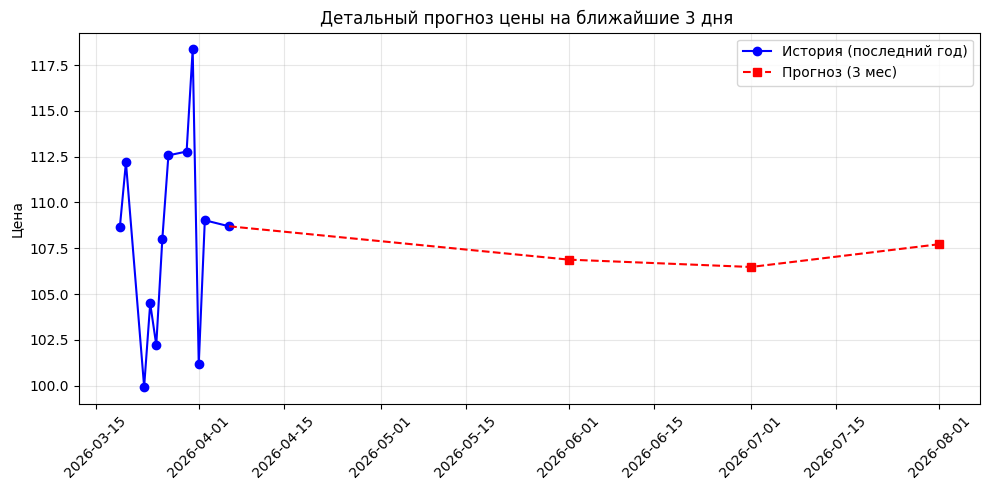

In [22]:
# Создание дат для прогноза
last_date = data.index[-1]
forecast_3m = prediction
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='MS')

# Вывод результата
forecast_df = pd.DataFrame(data=forecast_3m, index=forecast_dates, columns=['Прогноз'])
print("Прогноз на ближайшие 3 шага:")
print(forecast_df.round(2))

# Подготовка данных для графика
history_subset = data['price'][-12:] # Последние 12 месяцев для контекста
forecast_series = pd.Series(forecast_3m.flatten(), index=forecast_dates)

# Соединяем последнюю точку истории с первой точкой прогноза для непрерывности линии
connect_date = [history_subset.index[-1], forecast_series.index[0]]
connect_price = [history_subset.iloc[-1], forecast_series.iloc[0]]
# Построение графика
plt.figure(figsize=(10, 5))

# Отрисовка истории
plt.plot(history_subset.index, history_subset.values,
         label='История (последний год)', color='blue', marker='o')

# Отрисовка прогноза
plt.plot(forecast_series.index, forecast_series.values,
         label='Прогноз (3 мес)', color='red', linestyle='--', marker='s')

# Соединительная линия (пунктир)
plt.plot(connect_date, connect_price, color='red', linestyle='--')

plt.title('Детальный прогноз цены на ближайшие 3 дня ')
plt.ylabel('Цена')
plt.grid(True, alpha=0.3)
plt.legend()

# Настройка оси X для удобства чтения дат
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()